# Assignment 2

Before working on this assignment please read these instructions fully. In the submission area, you will notice that you can click the link to **Preview the Grading** for each step of the assignment. This is the criteria that will be used for peer grading. Please familiarize yourself with the criteria before beginning the assignment.

An NOAA dataset has been stored in the file `data/C2A2_data/BinnedCsvs_d400/fb441e62df2d58994928907a91895ec62c2c42e6cd075c2700843b89.csv`. This is the dataset to use for this assignment. Note: The data for this assignment comes from a subset of The National Centers for Environmental Information (NCEI) [Daily Global Historical Climatology Network](https://www1.ncdc.noaa.gov/pub/data/ghcn/daily/readme.txt) (GHCN-Daily). The GHCN-Daily is comprised of daily climate records from thousands of land surface stations across the globe.

Each row in the assignment datafile corresponds to a single observation.

The following variables are provided to you:

* **id** : station identification code
* **date** : date in YYYY-MM-DD format (e.g. 2012-01-24 = January 24, 2012)
* **element** : indicator of element type
    * TMAX : Maximum temperature (tenths of degrees C)
    * TMIN : Minimum temperature (tenths of degrees C)
* **value** : data value for element (tenths of degrees C)

For this assignment, you must:

1. Read the documentation and familiarize yourself with the dataset, then write some python code which returns a line graph of the record high and record low temperatures by day of the year over the period 2005-2014. The area between the record high and record low temperatures for each day should be shaded.
2. Overlay a scatter of the 2015 data for any points (highs and lows) for which the ten year record (2005-2014) record high or record low was broken in 2015.
3. Watch out for leap days (i.e. February 29th), it is reasonable to remove these points from the dataset for the purpose of this visualization.
4. Make the visual nice! Leverage principles from the first module in this course when developing your solution. Consider issues such as legends, labels, and chart junk.

The data you have been given is near **Ann Arbor, Michigan, United States**, and the stations the data comes from are shown on the map below.

<IPython.core.display.Javascript object>


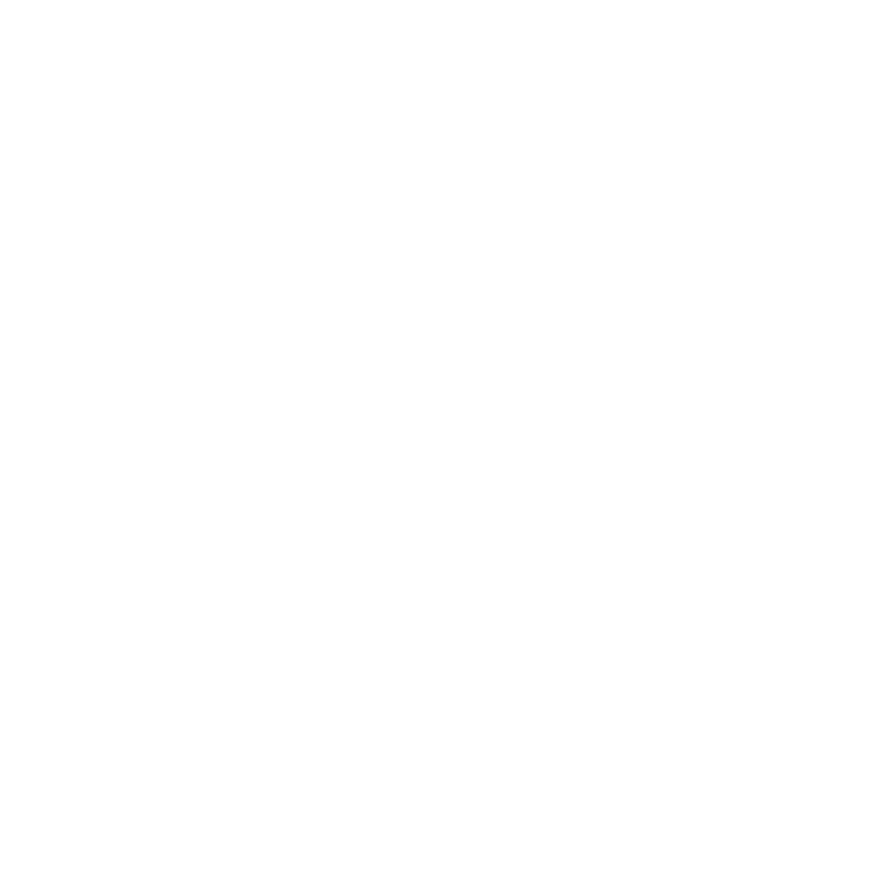

In [121]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplleaflet
import pandas as pd

def leaflet_plot_stations(binsize, hashid):

    df = pd.read_csv('data/C2A2_data/BinSize_d{}.csv'.format(binsize))

    station_locations_by_hash = df[df['hash'] == hashid]
    
    lons = station_locations_by_hash['LONGITUDE'].tolist()
    lats = station_locations_by_hash['LATITUDE'].tolist()

    plt.figure(figsize=(8,8))

    plt.scatter(lons, lats, c='r', alpha=0.7, s=200)

    return mplleaflet.display()

leaflet_plot_stations(400,'fb441e62df2d58994928907a91895ec62c2c42e6cd075c2700843b89')

In [84]:
pd.set_option('display.max_rows', 4)
#read data from csv
df = pd.read_csv('data/C2A2_data/BinnedCsvs_d400/fb441e62df2d58994928907a91895ec62c2c42e6cd075c2700843b89.csv')
df

,ID,Date,Element,Data_Value
0,USW00094889,2014-11-12,TMAX,22
1,USC00208972,2009-04-29,TMIN,56
...,...,...,...,...
165083,USC00200230,2006-11-29,TMIN,117
165084,USC00207312,2006-09-04,TMIN,111


In [55]:
# take data from 2005-2014 period
df_ten = df[(df['Date'] > '2005') & (df['Date'] < '2015')]
df_ten['Date'] = df_ten['Date'].apply(lambda x: '2015-' + x[5:])
df_ten = df_ten[~(df_ten['Date'] == '2015-02-29')]
df_ten

/opt/conda/lib/python3.6/site-packages/ipykernel/__main__.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  app.launch_new_instance()


,ID,Date,Element,Data_Value
0,USW00094889,2015-11-12,TMAX,22
1,USC00208972,2015-04-29,TMIN,56
...,...,...,...,...
165083,USC00200230,2015-11-29,TMIN,117
165084,USC00207312,2015-09-04,TMIN,111


In [56]:
# split data to tables with MIN and MAX temperatures
df_ten_min = df_ten[df_ten['Element'] == 'TMIN']
df_ten_max = df_ten[df_ten['Element'] == 'TMAX']
df_ten_min

,ID,Date,Element,Data_Value
1,USC00208972,2015-04-29,TMIN,56
6,USC00207308,2015-06-29,TMIN,144
...,...,...,...,...
165083,USC00200230,2015-11-29,TMIN,117
165084,USC00207312,2015-09-04,TMIN,111


In [57]:
# select MIN and MAX temperatures for each day of the year 
res_ten_min = df_ten_min.groupby('Date').agg({'Data_Value' : 'min'})
res_ten_max = df_ten_max.groupby('Date').agg({'Data_Value' : 'max'})
res_ten_min

,Data_Value
Date,
2015-01-01,-160
2015-01-02,-267
...,...
2015-12-30,-144
2015-12-31,-150


In [58]:
# prepare data for plotting
dates_range = list(map(pd.to_datetime, res_ten_min.index))
min_temp_data = list(map(lambda x: x/10, res_ten_min['Data_Value']))
max_temp_data = list(map(lambda x: x/10, res_ten_max['Data_Value']))

In [59]:
# select data from 2015 year
df_2015 = df[(df['Date'] > '2015') & (df['Date'] < '2016')]
df_2015 = df_2015[~(df_2015['Date'] == '2015-02-29')]
df_2015

,ID,Date,Element,Data_Value
19,USC00205563,2015-01-03,TMIN,-39
30,USC00203712,2015-03-17,TMAX,189
...,...,...,...,...
165072,USC00208080,2015-11-14,TMIN,-17
165080,USC00205822,2015-06-09,TMAX,256


In [61]:
# split data to tables with MIN and MAX temperatures
res_2015_min = df_2015[df_2015['Element'] == 'TMIN']
res_2015_max = df_2015[df_2015['Element'] == 'TMAX']
res_2015_min

,ID,Date,Element,Data_Value
19,USC00205563,2015-01-03,TMIN,-39
34,USC00200032,2015-06-06,TMIN,128
...,...,...,...,...
165059,USC00207312,2015-06-23,TMIN,172
165072,USC00208080,2015-11-14,TMIN,-17


In [62]:
# merge MIN data of 2015 and 2005-2014 and filter record low temperatures only 
df_2015_min_extra = res_2015_min.merge(res_ten_min, left_on = 'Date', right_index = True, 
                  suffixes = ['_2015', '_MIN'])[['Date', 'Data_Value_2015', 'Data_Value_MIN']]
df_2015_min_extra = df_2015_min_extra[df_2015_min_extra['Data_Value_2015'] < df_2015_min_extra['Data_Value_MIN']]
df_2015_min_extra

,Date,Data_Value_2015,Data_Value_MIN
17096,2015-01-05,-155,-150
8630,2015-08-28,56,67
...,...,...,...
142801,2015-02-20,-306,-178
152291,2015-02-15,-260,-256


In [63]:
# merge MAX data of 2015 and 2005-2014 and filter record high temperatures only 
df_2015_max_extra = res_2015_max.merge(res_ten_max, left_on = ['Date'], right_index = True, 
                  suffixes = ['_2015', '_MAX'])[['Date', 'Data_Value_2015', 'Data_Value_MAX']]
df_2015_max_extra = df_2015_max_extra[df_2015_max_extra['Data_Value_2015'] > df_2015_max_extra['Data_Value_MAX']]
df_2015_max_extra

,Date,Data_Value_2015,Data_Value_MAX
507,2015-12-13,167,111
2266,2015-12-13,161,111
...,...,...,...
156187,2015-09-17,294,289
157128,2015-09-17,294,289


In [64]:
# prepare data for MIN scatter
dates_range_min = list(map(pd.to_datetime, df_2015_min_extra['Date']))
min_temp_data_extra = list(map(lambda x: x/10, df_2015_min_extra['Data_Value_2015']))

In [65]:
# prepare data for MAX scatter
dates_range_max = list(map(pd.to_datetime, df_2015_max_extra['Date']))
max_temp_data_extra = list(map(lambda x: x/10, df_2015_max_extra['Data_Value_2015']))

<IPython.core.display.Javascript object>


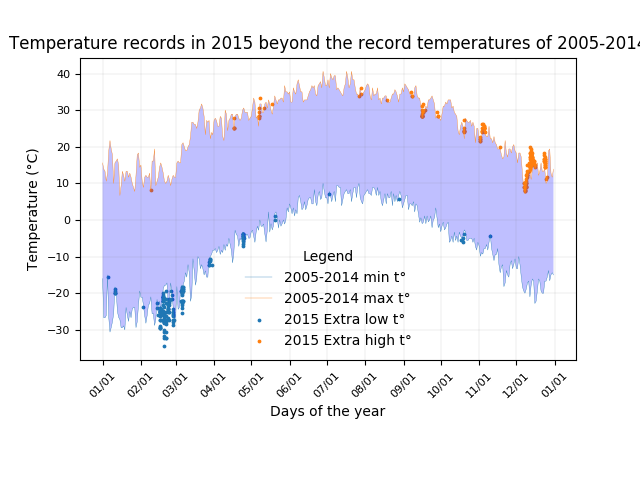

In [137]:
# graph build
%matplotlib notebook
plt.figure()
# plt.box(False)

plt.plot(dates_range, min_temp_data, '-', dates_range, max_temp_data, '-', linewidth=0.25)

plt.scatter(dates_range_min, min_temp_data_extra, s = 3)
plt.scatter(dates_range_max, max_temp_data_extra, s = 3)

# add labels to the axes and title
plt.xlabel('Days of the year')
plt.ylabel('Temperature (°C)')
plt.title('Temperature records in 2015 beyond the record temperatures of 2005-2014')
    
# add a legend
plt.legend(['2005-2014 min t°', '2005-2014 max t°', '2015 Extra low t°', '2015 Extra high t°'], frameon=False, title='Legend')

# add grid lines
ax = plt.gca()
ax.grid(color = 'gray',
        linewidth = 0.1,
        linestyle = '-')

# format dates view on x-axis
first_days_of_months = list(filter(lambda x: x.day == 1, dates_range))
first_days_of_months.append('2016-01-01')
ax.set_xticks(first_days_of_months)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# adjust the tick labels
for item in ax.xaxis.get_ticklabels():
    item.set_rotation(45)
    item.set_fontsize(8)
plt.subplots_adjust(bottom=0.25)

for item in ax.yaxis.get_ticklabels():
    item.set_fontsize(8)

# add fill area
ax.fill_between(dates_range, min_temp_data, max_temp_data, facecolor='blue', alpha=0.25)